# Description

This notebook generates a map of the studies. The output file is in EPS format.

# Requirements

An environment with:
- matplotlib
- pandas
- openpyxl
- geopandas

# Prerequisites

- An excel file ```filename``` containing the references in ```sheet_name``` with at least the column ```column_name```.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
filename = '../data/refs.xlsx'
sheet_name = 'RAW'
output_filename = "case_studies_map.eps"
column_name = 'Location'
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"


In [3]:
df = pd.read_excel(filename,sheet_name=sheet_name)
loc = df[column_name].to_list()
countries = pd.DataFrame(loc, columns=["country"])
df = countries.groupby('country').size().reset_index(name='count')

In [4]:
world = gpd.read_file(url)
world_counts = world.merge(df, left_on="NAME", right_on="country", how="left")
world_counts["count"] = world_counts["count"].fillna(0)

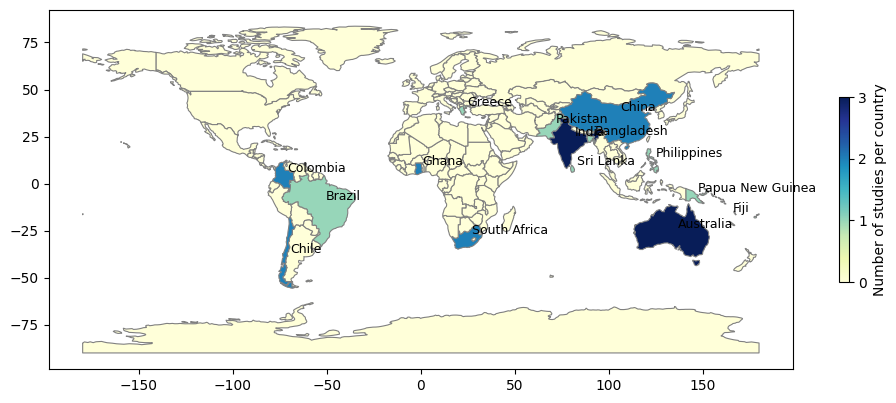

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))
world_counts.plot(
    column="count",       
    cmap="YlGnBu",  
    linewidth=0.8,
    ax=ax,
      edgecolor="grey",
    legend=True,
    legend_kwds={"label": "Number of studies per country",  "shrink": 0.3}
)

cbar = ax.get_figure().axes[-1]  
cbar.set_yticks(np.arange(int(world_counts["count"].min()),
                          int(world_counts["count"].max())+1, 1))

for idx, row in world_counts.iterrows():
    if row["NAME"] in df["country"].values:
      ax.annotate(row["NAME"], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                  xytext=(3, 3), textcoords="offset points", fontsize=9)

plt.savefig(output_filename, format="eps", bbox_inches="tight")

plt.show()